# asses the history of runs


In [1]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


/home/kandrych/venvs/obriy311/bin/python


backend: module://matplotlib_inline.backend_inline


In [2]:



df_original=pd.read_csv("/fred/oz061/kandrych/smac/20260827_edge_no_puffed_narow2_budget0_teperedp1p2_1000_no_subl_accr_second/smac_results/trials.csv")
results_dir="/fred/oz061/kandrych/smac/20260827_edge_no_puffed_narow2_budget0_teperedp1p2_1000_no_subl_accr_second/smac_results/after_optimisation/"
Path(results_dir).mkdir(parents=True, exist_ok=True)

exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "zone_1_Rref", 'additional_info'}
#Because I did not yet figured out how to deal with additional info column, I will drop it for now. It is not needed for the optimisation anyway.
df = df_original.drop(columns=['additional_info'])

param_cols = [c for c in df.columns if c not in exclude]
print(param_cols)

df


['alpha_viscosity', 'inclination', 'zone_1_Rc', 'zone_1_Rin', 'zone_1_Rout', 'zone_1_dust_mass', 'zone_1_edge', 'zone_1_flaring_exp', 'zone_1_scale_height', 'zone_1_species_1_aexp', 'zone_1_species_1_amax', 'zone_1_species_1_amin', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction', 'zone_1_surface_density_exp']


,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.010,1220.0,21.718388,63.446751,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.3,-0.146346,727,1570905720,0.1,16.252610,665.491328,1
1,0.010,1220.0,22.051142,65.476079,7.2,250,100,0.004,0.05,1.100822,...,0.1,0.3,0.5,-0.035768,847,1570905720,0.1,17.715312,639.333311,1
2,0.010,1220.0,21.718388,63.446751,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.3,-0.148630,442,1570905720,0.1,18.577650,621.233888,1
3,0.010,1220.0,21.703460,63.493718,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.3,-0.148630,685,1570905720,0.1,18.715207,564.593830,1
4,0.100,1220.0,23.830905,64.426344,7.2,250,100,0.004,0.05,1.084401,...,0.1,0.1,0.9,-0.312221,662,1570905720,0.1,18.853004,532.286971,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.010,1220.0,16.266368,69.855878,7.2,250,100,0.010,0.05,1.617793,...,0.1,0.8,0.8,-1.857381,991,1570905720,0.1,4526.338709,437.627583,1
996,0.100,1220.0,30.857256,177.675230,7.2,250,100,0.010,0.05,1.508799,...,0.1,0.6,0.7,-0.875784,764,1570905720,0.1,5150.800713,461.243279,1
997,0.010,1220.0,22.458736,112.081892,7.2,250,100,0.004,0.05,1.976230,...,0.1,0.8,0.9,-0.994198,85,1570905720,0.1,5317.356114,366.847151,1
998,0.001,1220.0,23.090717,175.325924,7.2,250,100,0.004,0.05,1.796249,...,0.1,0.8,0.8,-0.269228,668,1570905720,0.1,5700.664844,347.521040,1


### Best configs table (at max budget)

In [3]:
top = df[df["budget"] == df["budget"].max()].nsmallest(20, "cost")
print("Top 20 max budget trials:")
top
#top.to_csv(results_dir / "top5_maxbudget.csv", index=False)



Top 20 max budget trials:


,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.01,1220.0,21.718388,63.446751,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.3,-0.146346,727,1570905720,0.1,16.252610,665.491328,1
1,0.01,1220.0,22.051142,65.476079,7.2,250,100,0.004,0.05,1.100822,...,0.1,0.3,0.5,-0.035768,847,1570905720,0.1,17.715312,639.333311,1
2,0.01,1220.0,21.718388,63.446751,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.3,-0.148630,442,1570905720,0.1,18.577650,621.233888,1
3,0.01,1220.0,21.703460,63.493718,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.3,-0.148630,685,1570905720,0.1,18.715207,564.593830,1
4,0.10,1220.0,23.830905,64.426344,7.2,250,100,0.004,0.05,1.084401,...,0.1,0.1,0.9,-0.312221,662,1570905720,0.1,18.853004,532.286971,1
5,0.01,1220.0,21.723288,63.507437,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.3,-0.148630,659,1570905720,0.1,19.068014,600.134035,1
6,0.01,1220.0,21.805955,74.801250,7.2,250,100,0.002,0.05,1.100822,...,0.1,0.3,0.5,-0.063081,408,1570905720,0.1,19.161541,499.082985,1
7,0.01,1220.0,21.718388,63.496722,7.2,250,100,0.004,0.05,1.086288,...,0.1,0.3,0.9,-0.144275,710,1570905720,0.1,19.188957,640.694637,1
8,0.10,1220.0,21.805955,64.426344,7.2,250,100,0.004,0.05,1.084401,...,0.1,0.3,0.3,-0.142864,493,1570905720,0.1,19.218490,635.043441,1
9,0.01,1220.0,22.102221,63.446751,7.2,250,100,0.004,0.05,1.099991,...,0.1,0.3,0.5,-0.035584,822,1570905720,0.1,19.282014,587.586216,1


### Crashed runs inspection

In [4]:
df["status"] = np.where((df["cost"]==1e99) | (df["cost"]==df["cost"].max()), "Crashed", "Success")
df.loc[df['cost'] == df['cost'].max(), 'cost'] = 1e99


crashed_trials=df[df["status"]=="Crashed"]
successful_trials=df[df["status"]=="Success"]

crash_rate = len(crashed_trials) / len(df)
print('Rate of crashed trials to all trials:', crash_rate)

crashed_trials.describe().T.join(
   successful_trials.describe().T,
   lsuffix="_crashed",
   rsuffix="_successful"
)





Rate of crashed trials to all trials: 0.001


,count_crashed,mean_crashed,std_crashed,min_crashed,25%_crashed,50%_crashed,75%_crashed,max_crashed,count_successful,mean_successful,std_successful,min_successful,25%_successful,50%_successful,75%_successful,max_successful
alpha_viscosity,1.0,1.000000e-01,NaN,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,999.0,3.160225e-02,4.205179e-02,1.000000e-05,1.000000e-03,1.000000e-02,1.000000e-01,1.000000e-01
distance_pc,1.0,1.220000e+03,NaN,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,999.0,1.220000e+03,0.000000e+00,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03,1.220000e+03
inclination,1.0,2.586534e+01,NaN,2.586534e+01,2.586534e+01,2.586534e+01,2.586534e+01,2.586534e+01,999.0,2.494763e+01,6.083370e+00,1.503378e+01,2.170346e+01,2.215656e+01,2.864268e+01,3.998784e+01
zone_1_Rc,1.0,1.220562e+02,NaN,1.220562e+02,1.220562e+02,1.220562e+02,1.220562e+02,1.220562e+02,999.0,8.439563e+01,3.798797e+01,2.009851e+01,6.344675e+01,6.970209e+01,9.726239e+01,1.998829e+02
zone_1_Rin,1.0,7.200000e+00,NaN,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,999.0,7.200000e+00,1.208528e-13,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00,7.200000e+00
zone_1_Rout,1.0,2.500000e+02,NaN,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,999.0,2.500000e+02,0.000000e+00,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02,2.500000e+02
zone_1_Rref,1.0,1.000000e+02,NaN,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,999.0,1.000000e+02,0.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
zone_1_dust_mass,1.0,4.000000e-03,NaN,4.000000e-03,4.000000e-03,4.000000e-03,4.000000e-03,4.000000e-03,999.0,3.130731e-03,2.474112e-03,1.000000e-04,2.000000e-03,2.000000e-03,4.000000e-03,1.000000e-02
zone_1_edge,1.0,5.000000e-02,NaN,5.000000e-02,5.000000e-02,5.000000e-02,5.000000e-02,5.000000e-02,999.0,5.000000e-02,7.011793e-16,5.000000e-02,5.000000e-02,5.000000e-02,5.000000e-02,5.000000e-02
zone_1_flaring_exp,1.0,1.997729e+00,NaN,1.997729e+00,1.997729e+00,1.997729e+00,1.997729e+00,1.997729e+00,999.0,1.198750e+00,2.490467e-01,8.039533e-01,1.085799e+00,1.100822e+00,1.201456e+00,1.994114e+00


In [5]:
from pandas.api.types import is_numeric_dtype

def plot_crash_success_histograms(df, crashed, success, param_cols, results_dir=None, max_unique=20, nbins=30):

    crash_rate = len(crashed) / len(df)
    fig, axes = plt.subplots(
        len(param_cols), 1,
        figsize=(6, 3 * len(param_cols))
    )

    if len(param_cols) == 1:
        axes = [axes]

    
    for ax, p in zip(axes, param_cols):

        if is_numeric_dtype(df[p]):

            x_all = df[p].dropna()
            x_crash = crashed[p].dropna()
            x_success = success[p].dropna()

            unique = np.sort(x_all.unique())

            if len(unique) <= 20:
                crash_counts = x_crash.value_counts().reindex(unique, fill_value=0)
                success_counts = x_success.value_counts().reindex(unique, fill_value=0)

                xpos = np.arange(len(unique))
                width = 0.4

                ax.bar(xpos-width/2, crash_counts, width, label="Crash")
                ax.bar(xpos+width/2, success_counts, width, alpha=0.6, label="Success")

                ax.set_xticks(xpos)
                ax.set_xticklabels(unique, rotation=45)

            else:
                ax.hist(x_crash, bins=30, alpha=1, label="Crash")
                ax.hist(x_success, bins=30, alpha=0.6, label="Success")

        else:
            # Categorical parameter
            categories = df[p].dropna().unique()

            crash_counts = (
                crashed[p]
                .value_counts()
                .reindex(categories, fill_value=0)
            )

            success_counts = (
                success[p]
                .value_counts()
                .reindex(categories, fill_value=0)
            )

            xpos = np.arange(len(categories))
            width = 0.4

            ax.bar(xpos-width/2, crash_counts, width, label="Crash")
            ax.bar(xpos+width/2, success_counts, width, alpha=0.6, label="Success")

            ax.set_xticks(xpos)
            ax.set_xticklabels(categories, rotation=45)

        ax.set_xlabel(p)
        ax.legend()

    plt.tight_layout()

    plt.suptitle('Rate of crashed trials to all trials: {:.2f}'.format(crash_rate), fontsize=12, y=1.01)

    if results_dir is not None:
        plt.savefig(results_dir + "Histograms_crashed_vs_successful.png", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()

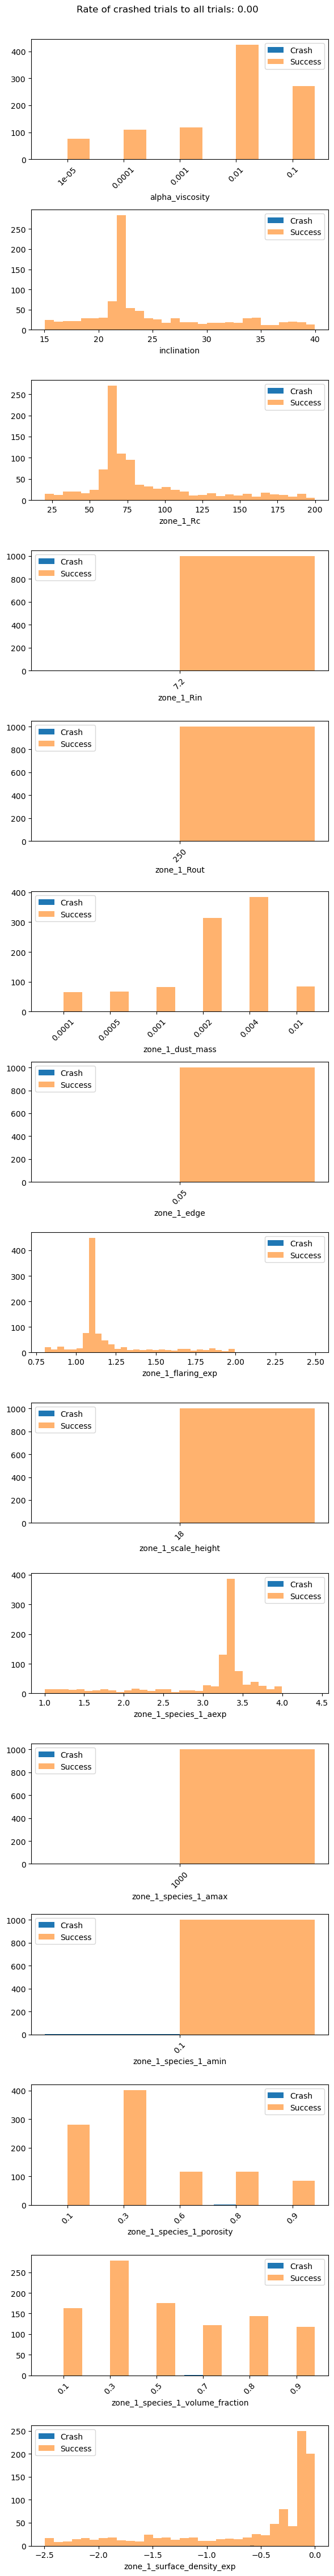

In [6]:
plot_crash_success_histograms(df, crashed_trials, successful_trials, param_cols, results_dir=results_dir, max_unique=20, nbins=30)

### Pairwise sanity checks (parameter vs cost)


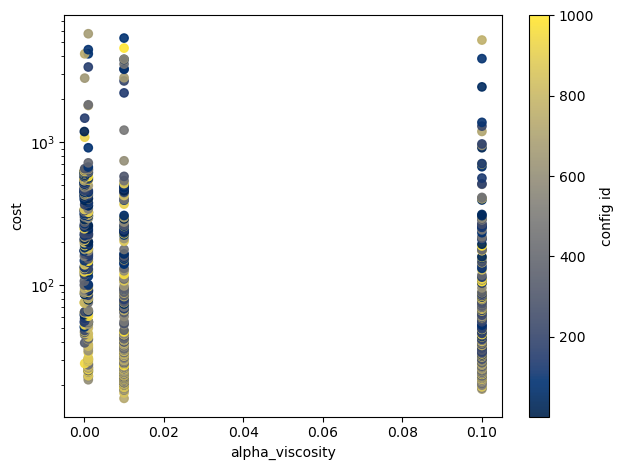

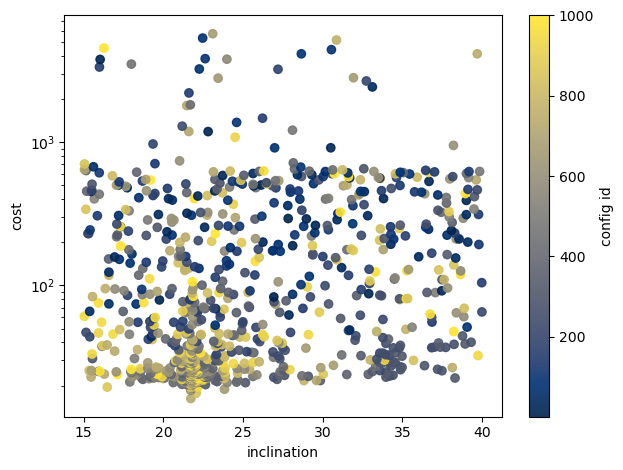

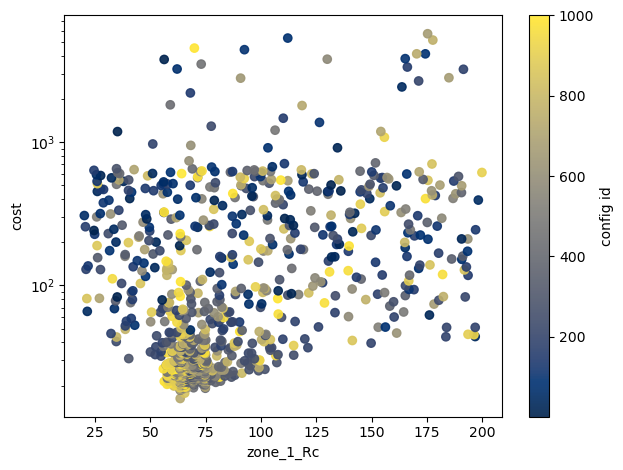

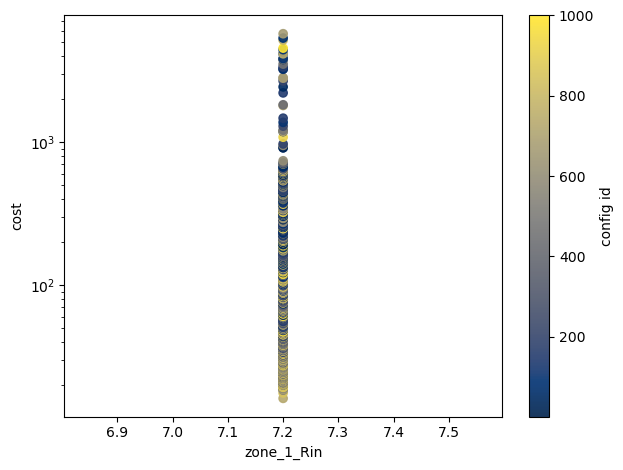

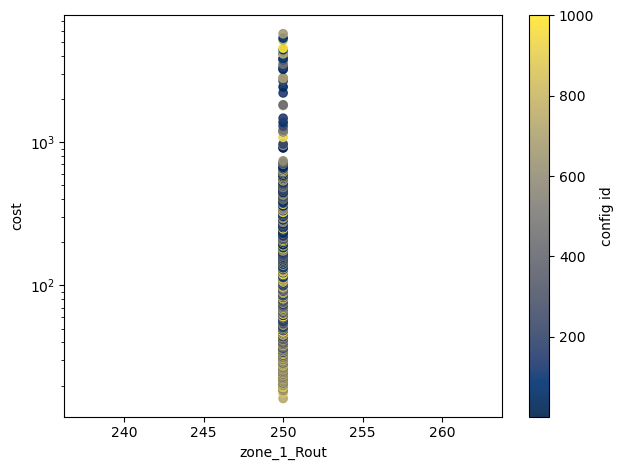

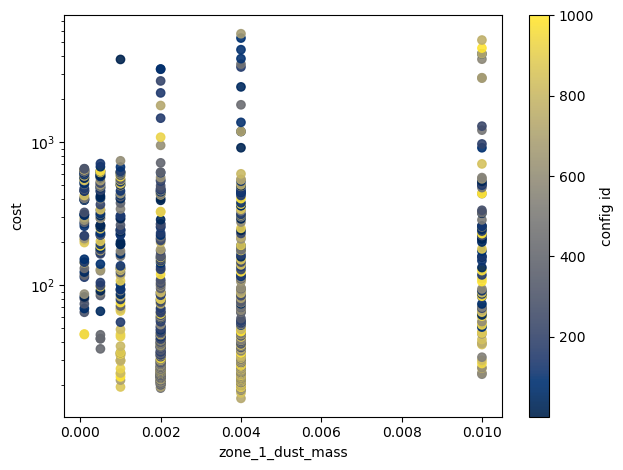

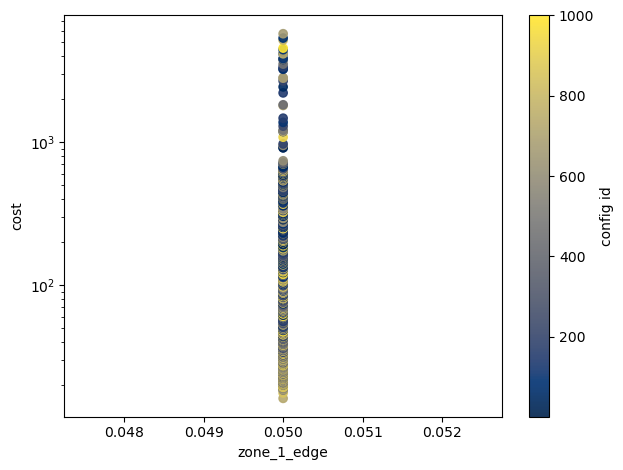

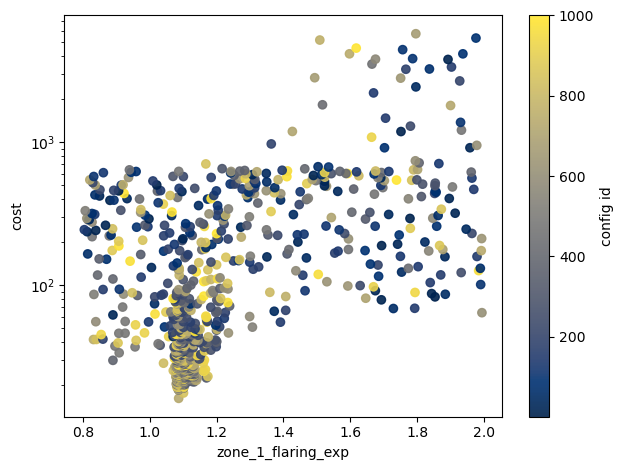

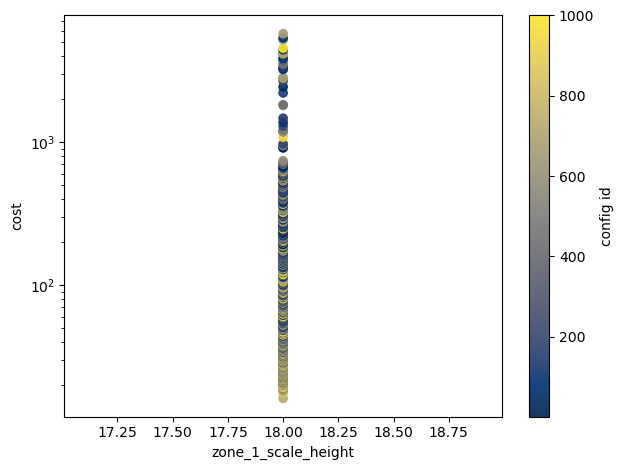

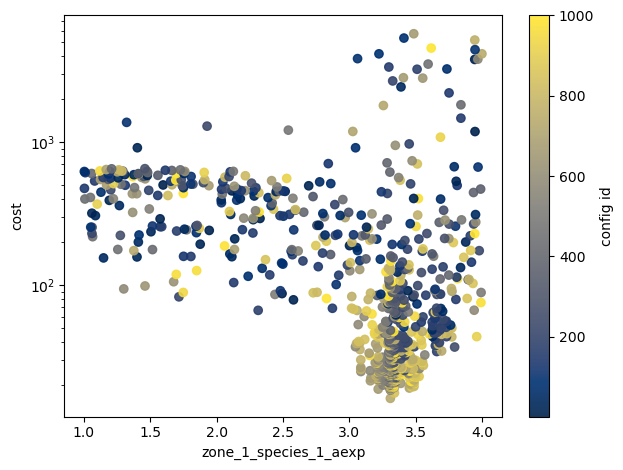

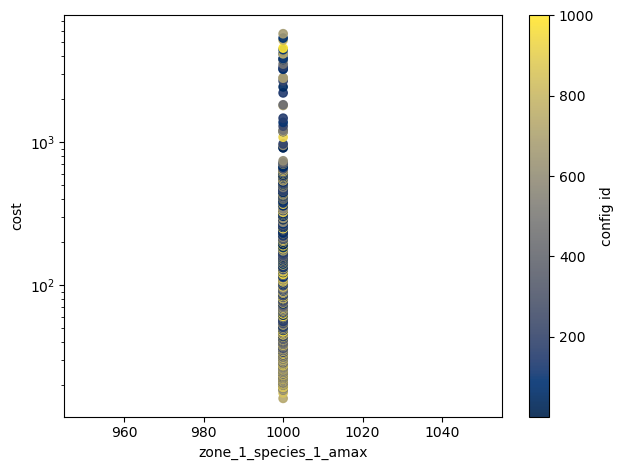

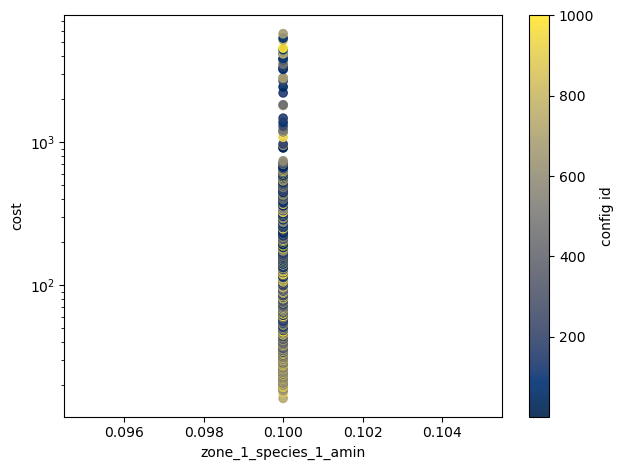

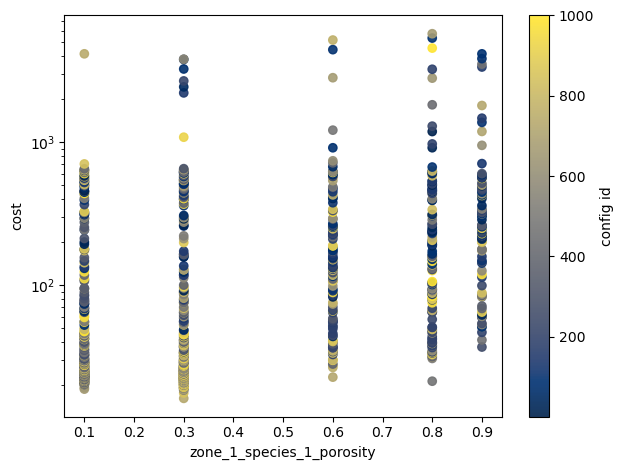

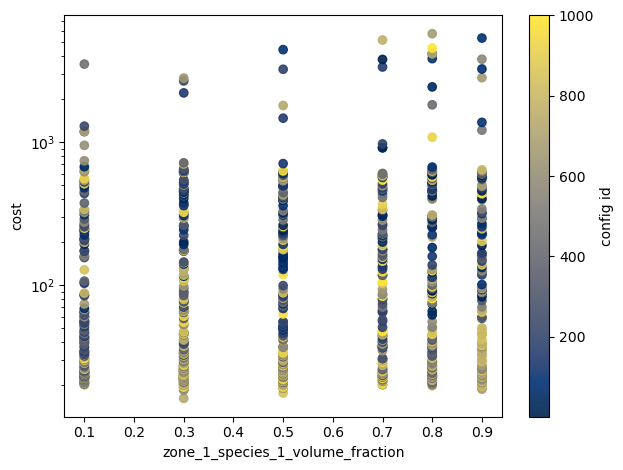

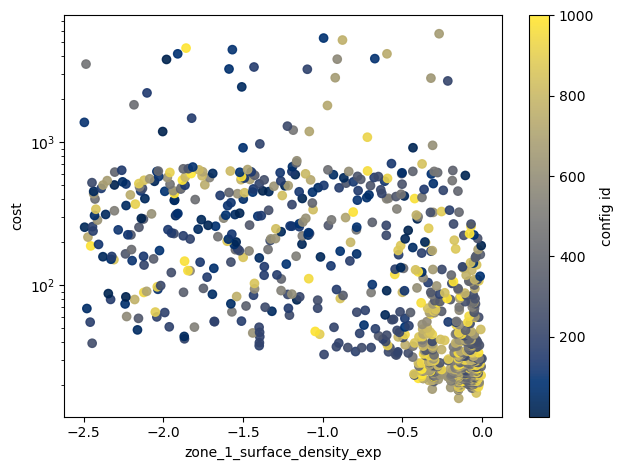

In [7]:


for p in param_cols:  # rename to your actual names
    if p in df.columns:
        plt.figure()
        sc=plt.scatter(successful_trials[p], successful_trials["cost"], c=successful_trials["config_id"], cmap='cividis', alpha=0.9)
        plt.xlabel(p)
        plt.ylabel("cost")
        cbar = plt.colorbar(sc)
        cbar.set_label("config id")

        plt.yscale("log")  # often helpful
        plt.tight_layout()
        plt.savefig(results_dir +f"scatter_{p}.png", dpi=150)
        plt.show()
        plt.close()


### Slice by budget (does the story change with fidelity?)

In [8]:
successful_trials.groupby("budget")["cost"].describe()#.to_csv(results_dir / "cost_by_budget.csv")


,count,mean,std,min,25%,50%,75%,max
budget,,,,,,,,
0.1,999.0,218.000623,551.439056,16.25261,24.812329,42.196101,210.229745,5700.664844


### Parameter importance (fast, practical)

In [9]:
def binned_medians(successful_trials, param, bins=2):
    s = successful_trials[[param, "cost"]].dropna()
    s["bin"] = pd.qcut(s[param], q=bins, duplicates="drop")
    return s.groupby("bin", observed=True)["cost"].median().sort_values()

for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:
    if p in successful_trials.columns:
        bm = binned_medians(successful_trials[successful_trials["budget"] == successful_trials["budget"].max()], p)
        print(f"Binned medians for {p}:")
        print(bm)
        #bm.to_csv(results_dir / f"binned_median_{p}.csv")


Binned medians for zone_1_Rc:
bin
(20.098, 69.702]     27.797424
(69.702, 199.883]    89.384855
Name: cost, dtype: float64
Binned medians for zone_1_flaring_exp:
bin
(0.803, 1.101]     28.359060
(1.101, 1.994]    115.631518
Name: cost, dtype: float64
Binned medians for zone_1_dust_mass:
bin
(0.002, 0.01]       28.654020
(-0.0009, 0.002]    71.706521
Name: cost, dtype: float64
Binned medians for zone_1_species_1_porosity:
bin
(0.099, 0.3]     27.501338
(0.3, 0.9]      174.778558
Name: cost, dtype: float64


### Clustering of “good” solutions (degeneracies)

In [10]:

percent_of_successful = len(successful_trials)*0.1

good = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].nsmallest(int(percent_of_successful), "cost")
good.describe()#.to_csv(results_dir / "good5_summary.csv")

,alpha_viscosity,distance_pc,inclination,zone_1_Rc,zone_1_Rin,zone_1_Rout,zone_1_Rref,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,...,zone_1_species_1_amax,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time
count,99.000000,99.0,99.000000,99.000000,9.900000e+01,99.0,99.0,99.000000,9.900000e+01,99.000000,...,99.0,9.900000e+01,99.000000,99.000000,99.000000,99.000000,9.900000e+01,9.900000e+01,99.000000,99.000000
mean,0.022636,1220.0,22.067913,66.881173,7.200000e+00,250.0,100.0,0.003333,5.000000e-02,1.095375,...,1000.0,1.000000e-01,0.242424,0.469697,-0.120155,652.767677,1.570906e+09,1.000000e-01,20.800779,572.623932
std,0.031570,0.0,1.659213,5.237789,6.248889e-15,0.0,0.0,0.000979,9.763889e-17,0.013622,...,0.0,1.952778e-16,0.108882,0.261259,0.067805,188.843788,0.000000e+00,1.952778e-16,1.069976,88.591288
min,0.001000,1220.0,16.474187,56.240892,7.200000e+00,250.0,100.0,0.001000,5.000000e-02,1.079139,...,1000.0,1.000000e-01,0.100000,0.100000,-0.333892,318.000000,1.570906e+09,1.000000e-01,16.252610,390.245999
25%,0.010000,1220.0,21.718388,63.446751,7.200000e+00,250.0,100.0,0.002000,5.000000e-02,1.086203,...,1000.0,1.000000e-01,0.100000,0.300000,-0.148383,495.000000,1.570906e+09,1.000000e-01,20.265930,490.242463
50%,0.010000,1220.0,21.772305,64.426344,7.200000e+00,250.0,100.0,0.004000,5.000000e-02,1.090519,...,1000.0,1.000000e-01,0.300000,0.300000,-0.142726,662.000000,1.570906e+09,1.000000e-01,21.004753,584.550293
75%,0.010000,1220.0,22.047341,69.779296,7.200000e+00,250.0,100.0,0.004000,5.000000e-02,1.100822,...,1000.0,1.000000e-01,0.300000,0.700000,-0.063077,806.000000,1.570906e+09,1.000000e-01,21.644294,634.275515
max,0.100000,1220.0,29.843459,81.704789,7.200000e+00,250.0,100.0,0.004000,5.000000e-02,1.139533,...,1000.0,1.000000e-01,0.800000,0.900000,-0.018244,979.000000,1.570906e+09,1.000000e-01,22.110609,862.808701


### Plot

In [11]:
curve = successful_trials.groupby(["config_id", "budget"])["cost"].min().reset_index()
curve#.to_csv(results_dir / "learning_curves.csv", index=False)


,config_id,budget,cost
0,1,0.1,83.019411
1,2,0.1,1183.630310
2,3,0.1,456.235139
3,4,0.1,501.603826
4,5,0.1,292.853300
...,...,...,...
994,996,0.1,542.715978
995,997,0.1,25.998988
996,998,0.1,23.929939
997,999,0.1,602.630923


## For the cornerplot


SMAC does not give a true posterior.
This corner plot represents a high-likelihood region sampled by Bayesian optimisation, not an MCMC posterior.
So... distribution of high-performing models:

In [12]:
# Restrict to highest fidelity
df_max = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].copy()

# Drop failed / NaN
df_max = df_max.dropna(subset=["cost"])

# Optional: keep only the best 30% of trials
q = 0.9
cost_cut = df_max["cost"].quantile(q)
df_sel = df_max[df_max["cost"] <= cost_cut]


In [13]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "zone_1_Rref"}

param_cols = [c for c in df_sel.columns if c not in exclude]
param_cols


['alpha_viscosity',
 'inclination',
 'zone_1_Rc',
 'zone_1_Rin',
 'zone_1_Rout',
 'zone_1_dust_mass',
 'zone_1_edge',
 'zone_1_flaring_exp',
 'zone_1_scale_height',
 'zone_1_species_1_aexp',
 'zone_1_species_1_amax',
 'zone_1_species_1_amin',
 'zone_1_species_1_porosity',
 'zone_1_species_1_volume_fraction',
 'zone_1_surface_density_exp']

In [14]:
#just one function to do it
#WORKS

def make_corner_plot(
    df,
    params,
    *,
    budget=None,
    best_quantile=0.3,
    title=None,
    outfile="corner.png",
):

    d = df.copy()
    if budget is not None:
        d = d[d["budget"] == budget]

    d = d.dropna(subset=["cost"])
    cost_cut = d["cost"].quantile(best_quantile)
    d = d[d["cost"] <= cost_cut]
    if len(d) == 0:
        print("No data to plot after filtering by budget and cost quantile.")
        return
    params_corner = []
    for p in params:
        if p not in d.columns:
            raise ValueError(f"Parameter '{p}' not found in DataFrame columns.")
        if d[p].unique().size >= 2:
            params_corner.append(p)
        else:
            print(f"Parameter '{p}' has less than 2 unique values in the filtered DataFrame.")


    if len(params_corner) == 0:
        print("No valid parameters to plot after filtering.")
        return
    data = d[params_corner].values

    fig = corner.corner(
        data,
        labels=params_corner,
        quantiles=[0.16, 0.5, 0.84],
        weights=1.0 / d["cost"].values,
        show_titles=True,
        wrap_title_quantiles=True,
        title_fmt=".3g"  
    )
    plt.suptitle(title, fontsize=14, y=1.01)
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)




        zone_1_Rc  zone_1_flaring_exp  zone_1_dust_mass  \
count  899.000000          899.000000        899.000000   
mean    82.077327            1.162221          0.003181   
std     36.011206            0.213280          0.002353   
min     20.098513            0.803953          0.000100   
25%     63.446751            1.085078          0.002000   
50%     69.149412            1.098196          0.002000   
75%     88.900292            1.148268          0.004000   
max    198.251345            1.994114          0.010000   

       zone_1_species_1_porosity  
count                 899.000000  
mean                    0.374750  
std                     0.265828  
min                     0.100000  
25%                     0.100000  
50%                     0.300000  
75%                     0.600000  
max                     0.900000  


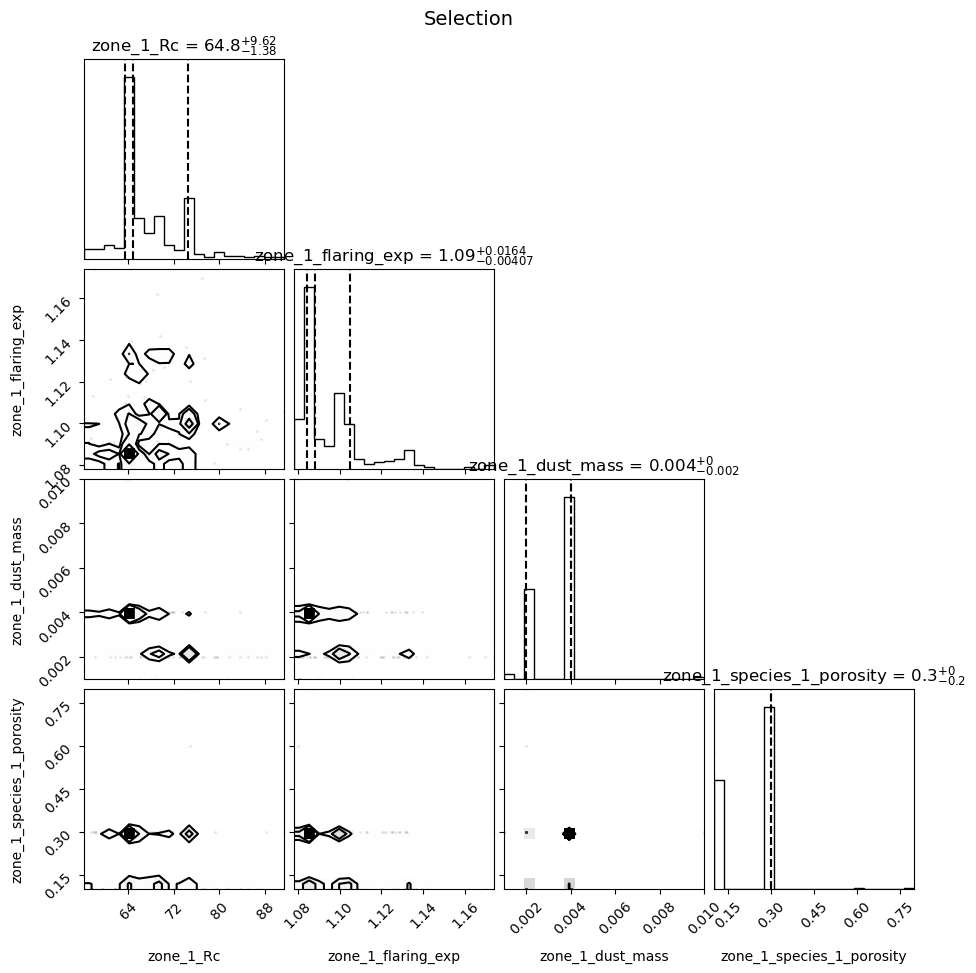

In [15]:
param_cols=["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]
print(df_sel[param_cols].describe())

make_corner_plot(
    df_sel,
    params=param_cols,
    budget=df_sel["budget"].max(),
    outfile=results_dir+ "corner_best.png",
    title="Selection"
)


## setting up subgroups of parameters for corner plots

Parameters for 'Grid setup parameters': []
[]
Parameters for 'Disk orientation parameters': ['distance_pc']
Parameter 'distance_pc' has less than 2 unique values in the filtered DataFrame.
[]
Parameters for 'Disk geometry parameters': ['zone_1_Rc', 'zone_1_Rin', 'zone_1_Rout', 'zone_1_Rref', 'zone_1_edge', 'zone_1_flaring_exp', 'zone_1_scale_height', 'zone_1_surface_density_exp']
Parameter 'zone_1_Rin' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_Rout' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_Rref' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_edge' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_scale_height' has less than 2 unique values in the filtered DataFrame.
['zone_1_Rc', 'zone_1_flaring_exp', 'zone_1_surface_density_exp']
Corner plot for Disk geometry parameters:


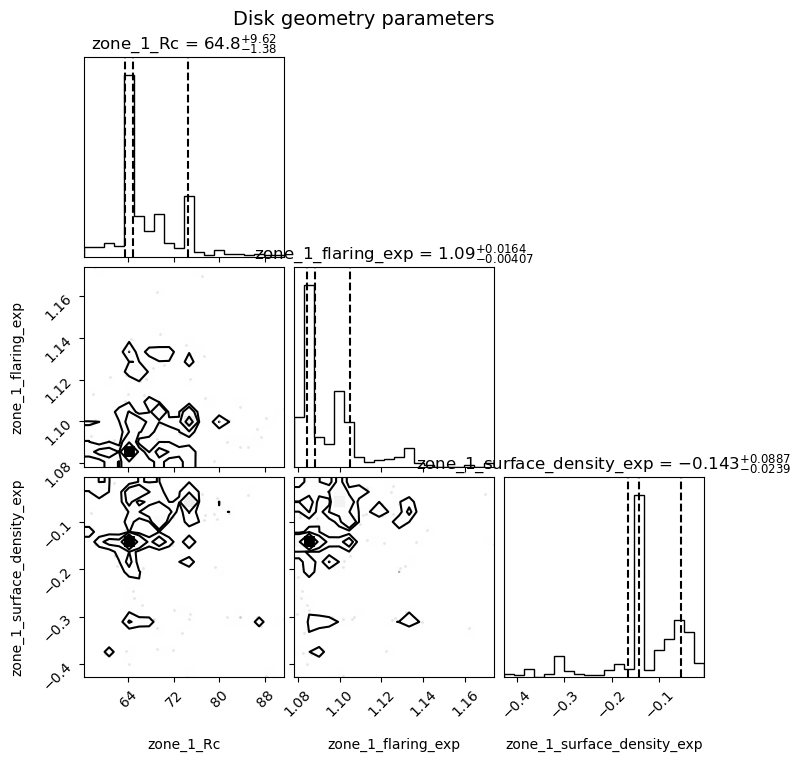

Parameters for 'Dust distribution parameters': ['alpha_viscosity', 'zone_1_dust_mass']
['alpha_viscosity', 'zone_1_dust_mass']
Corner plot for Dust distribution parameters:


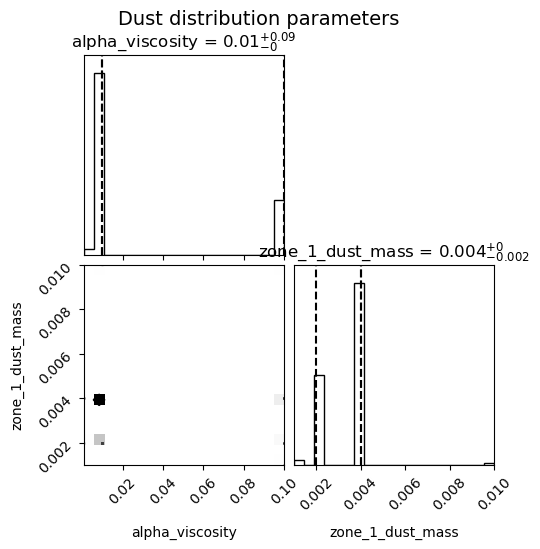

Parameters for 'Dust grain parameters': ['zone_1_species_1_aexp', 'zone_1_species_1_amax', 'zone_1_species_1_amin', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction']
Parameter 'zone_1_species_1_amax' has less than 2 unique values in the filtered DataFrame.
Parameter 'zone_1_species_1_amin' has less than 2 unique values in the filtered DataFrame.
['zone_1_species_1_aexp', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction']
Corner plot for Dust grain parameters:


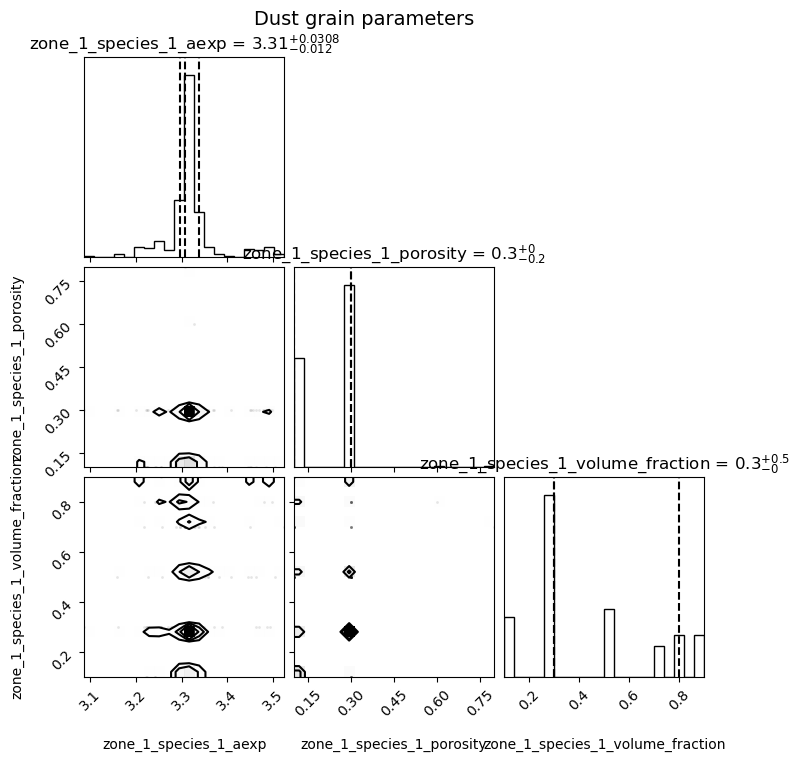

Parameters for 'Star parameters': []
[]


In [16]:
#all parameters

grid_setup_parameters=["grid_geometry", "n_rad", "nz", "n_az", "n_rad_in", "grid_nx", "grid_ny", "grid_size"]
disk_orientation_parameters=["imin", "imax", "n_incl", "centered", "az_min", "az_max", "distance_pc", "disk_pa"]
disk_geometry_parameters=["zone_1_scale_height", "zone_1_Rref", "zone_1_vertical_profile_exponent", "zone_1_Rin", "zone_1_edge", "zone_1_Rout", "zone_1_Rc", "zone_1_flaring_exp", "zone_1_surface_density_exp", "zone_1_-gamma_exp"]
dust_distribution_parameters=["dust_settling", "exp_strat", "a_strat", "dust_radial_migration", "sublimate_dust", "hydrostatic_equilibrium", "viscous_heating", "alpha_viscosity",
                          "zone_1_dust_mass", "zone_1_gas_to_dust"]
dust_grain_parameters=["zone_1_species_1_grain_type", "zone_1_species_1_N_components", "zone_1_species_1_mixing_rule", "zone_1_species_1_porosity", "zone_1_species_1_mass_fraction", "zone_1_species_1_Vmax", "zone_1_species_1_optical_indices_file", "zone_1_species_1_volume_fraction", "zone_1_species_1_heating_method",
                       "zone_1_species_1_amin", "zone_1_species_1_amax", "zone_1_species_1_aexp", "zone_1_species_1_n_grains"]
star_parameters=["star_1_Temp", "star_1_R", "star_1_M", "star_1_x", "star_1_y", "star_1_z", "star_1_autometic_spectrum", "star_1_spectrum_file", "star_1_fUV", "star_1_slope_fUV"]  


titles={"Grid setup parameters": grid_setup_parameters,
        "Disk orientation parameters": disk_orientation_parameters,
        "Disk geometry parameters": disk_geometry_parameters,
        "Dust distribution parameters": dust_distribution_parameters,
        "Dust grain parameters": dust_grain_parameters,
        "Star parameters": star_parameters}

for title in titles.keys():
    param_subset = titles[title]
    param_cols_set = [c for c in df_sel.columns if c in param_subset]
    param_cols_corner = []  # Initialize a list to keep track of parameters with less than 2 unique values
    print(f"Parameters for '{title}': {param_cols_set}")
    for p in param_cols_set:
        if df_sel[p].unique().size >= 2:
            param_cols_corner.append(p) 
        else:
            print(f"Parameter '{p}' has less than 2 unique values in the filtered DataFrame.")

    print(param_cols_corner)

    if len(param_cols_corner)>1:
        print(f"Corner plot for {title}:")
        
        #print(df_sel[param_cols_set].describe())

        make_corner_plot(
            df_sel,
            params=param_cols_corner,
            budget=df_sel["budget"].max(),
            title=title,
            outfile=results_dir+ f"corner_{title}_best.png"
        )

